Question
Do the key degradation sensors exhibit stronger or more noticeable changes as engines approach end of their useful life.

Objective
Analyze Sensors 4,7,11,12,15 during the later stages of normalized engine life to determine whether their behaviour provides evidence of increasing engine degradation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
column_names=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}" for i in range(1,22)]

df=pd.read_csv('../data/raw/train_FD001.txt',sep=r'\s+',header=None)

df.columns=column_names

df["max_cycle"]=df.groupby("engine_id")["cycle"].transform("max")
df["life_percent"]= (df["cycle"]/df["max_cycle"])*100

key_sensors=['sensor_4','sensor_7','sensor_11','sensor_12','sensor_15']

In [5]:
late_life=df[df['life_percent']>=60]

late_life.shape

(8316, 28)

In [6]:
df["life_stage"]=pd.cut(df['life_percent'],bins=[0,25,50,75,100],labels=['0-25%', '25-50%', '50-75%', '75-100%'])

df[['life_percent','life_stage']].head()

,life_percent,life_stage
0,0.520833,0-25%
1,1.041667,0-25%
2,1.562500,0-25%
3,2.083333,0-25%
4,2.604167,0-25%


In [7]:
stage_means=df.groupby('life_stage',observed=True)[key_sensors].mean()

stage_means

,sensor_4,sensor_7,sensor_11,sensor_12,sensor_15
life_stage,,,,,
0-25%,1402.775563,553.946116,47.354500,521.909060,8.418241
25-50%,1404.598426,553.785298,47.408699,521.768277,8.424682
50-75%,1408.663083,553.392062,47.534371,521.433810,8.440875
75-100%,1419.582929,552.358220,47.863622,520.552011,8.484333


In [8]:
early= stage_means.loc['0-25%']
late=stage_means.loc['75-100%']

percent_change=((late-early)/ early.abs())*100

percent_change

sensor_4     1.198151
sensor_7    -0.286652
sensor_11    1.075130
sensor_12   -0.260016
sensor_15    0.785108
dtype: float64

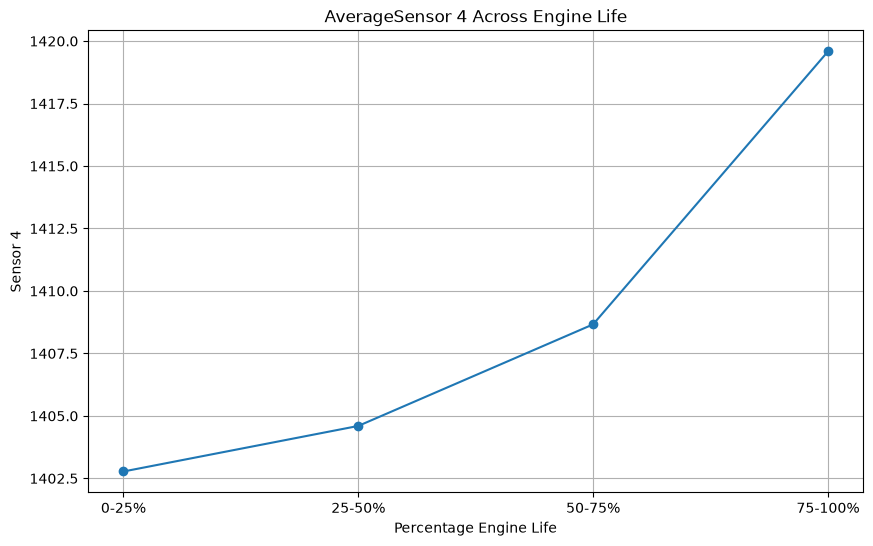

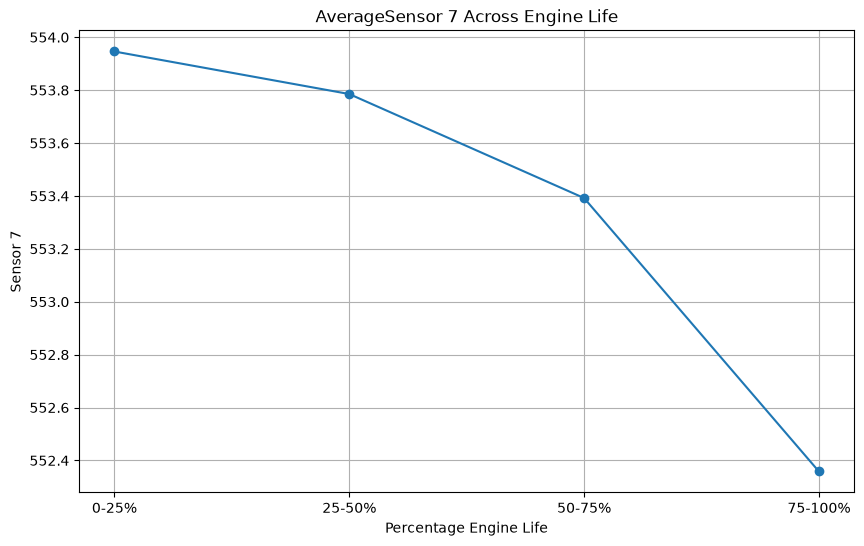

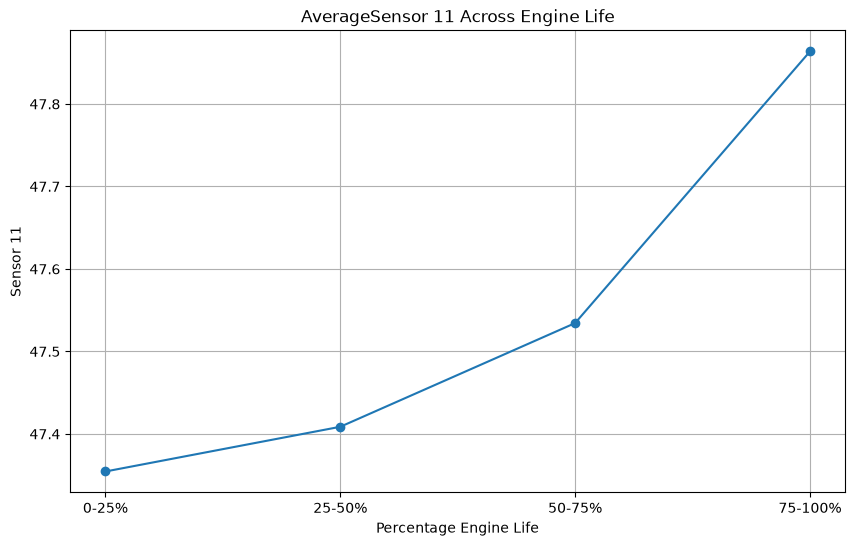

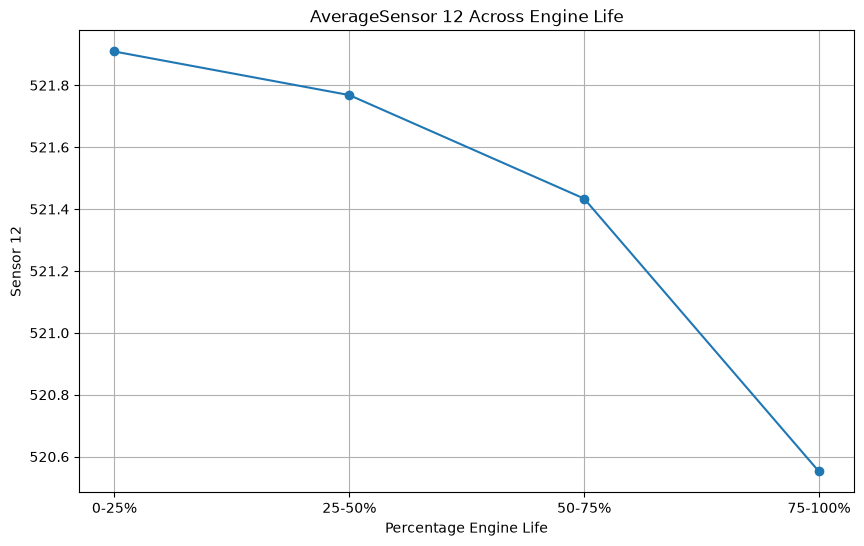

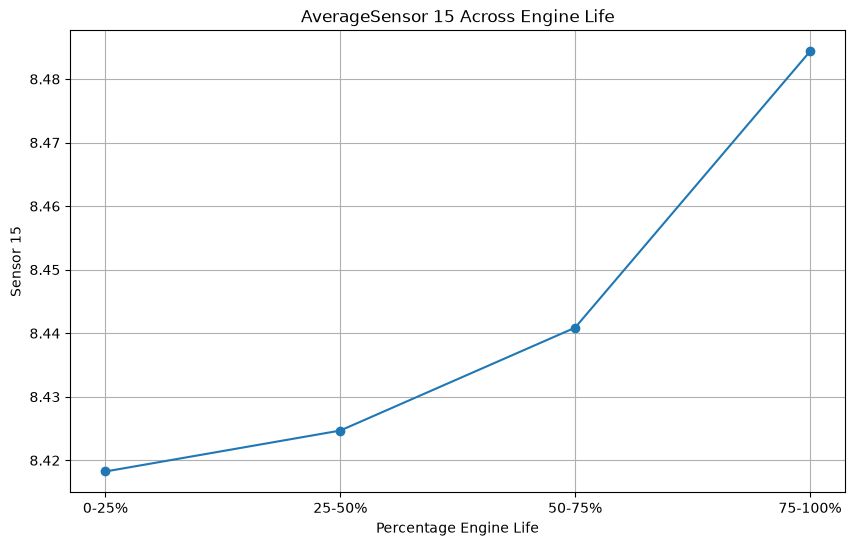

In [9]:
for sensor in key_sensors:
    grouped=df.groupby('life_stage')[sensor].mean()
    
    plt.figure(figsize=(10,6))
    plt.plot(grouped.index,grouped.values,marker='o')
    
    plt.title(f'Average{sensor.replace('_',' ').title()} Across Engine Life')
    plt.xlabel('Percentage Engine Life')
    plt.ylabel(sensor.replace('_',' ').title())
    plt.grid(True)
    plt.show()
    

Observations: 

 Sensor 4: A positive slope is observed across all life intervals (0–25%, 25–50%, 50–75%, and 75–100%). The slope progressively increases as engine life advances, with the largest increase occurring from 75–100%, indicating a sharper rise near the end of life.
 Sensor 7: A negative slope is observed across all intervals. The slope becomes progressively more negative as engine life increases, with the largest decrease in slope occurring from 75–100%, indicating a sharper decline near the end of life.
 Sensor 11: Similar to Sensor 4, Sensor 11 maintains a positive slope throughout all intervals, with the slope becoming progressively steeper as the engine approaches the end of its life.
 Sensor 12: Similar to Sensor 7, Sensor 12 shows a negative slope across all intervals. The slope becomes increasingly negative as engine life progresses, with the steepest decline occurring from 75–100%.
Sensor 15: Sensor 15 follows a similar increasing trend to Sensors 4 and 11. All intervals show a positive slope, with the slope increasing as engine life progresses and the largest increase occurring between 50–75% and 75–100%.


In [11]:
df['late_stage']=pd.cut(df['life_percent'],bins=[60,80,100],labels=['60-80%','80-100%'],include_lowest=True)

late_stage_means=df.groupby('late_stage',observed=True)[key_sensors].mean()

late_stage_means

,sensor_4,sensor_7,sensor_11,sensor_12,sensor_15
late_stage,,,,,
60-80%,1410.713600,553.192511,47.595991,521.261640,8.449617
80-100%,1421.098307,552.213997,47.910468,520.429729,8.490335


In [12]:
late_change=(late_stage_means.loc['80-100%'])-late_stage_means.loc['60-80%']

late_change

sensor_4     10.384707
sensor_7     -0.978514
sensor_11     0.314478
sensor_12    -0.831911
sensor_15     0.040718
dtype: float64

In [14]:
late_change_table= pd.DataFrame({'Sensor':key_sensors,'Change 60to80 vs 80 to100':[late_change[sensor]for sensor in key_sensors]})

late_change_table

,Sensor,Change 60to80 vs 80 to100
0,sensor_4,10.384707
1,sensor_7,-0.978514
2,sensor_11,0.314478
3,sensor_12,-0.831911
4,sensor_15,0.040718


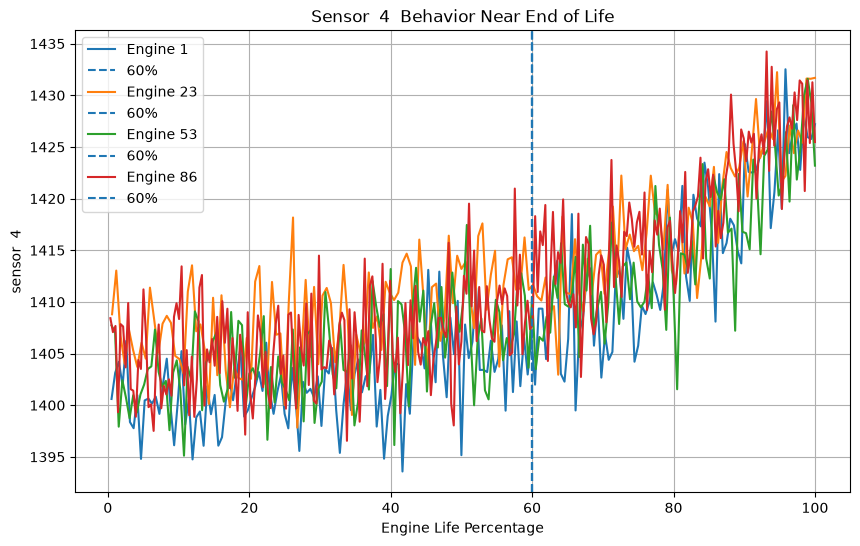

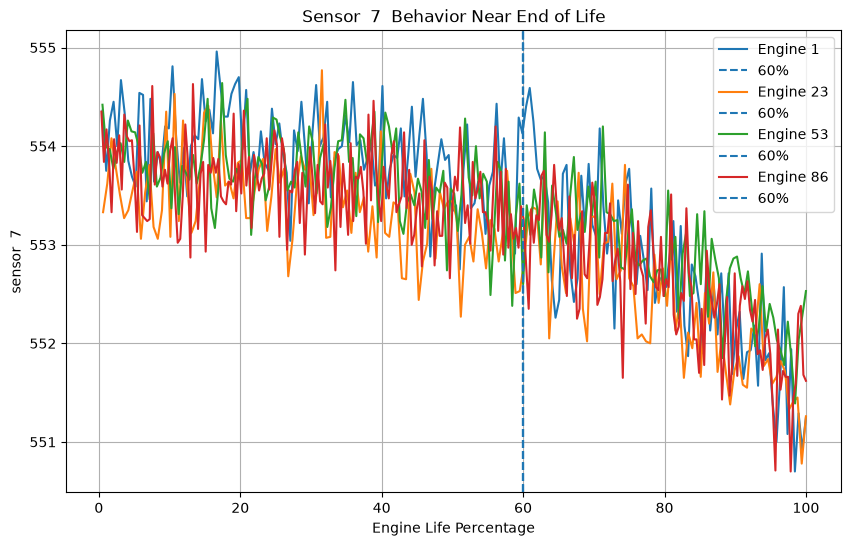

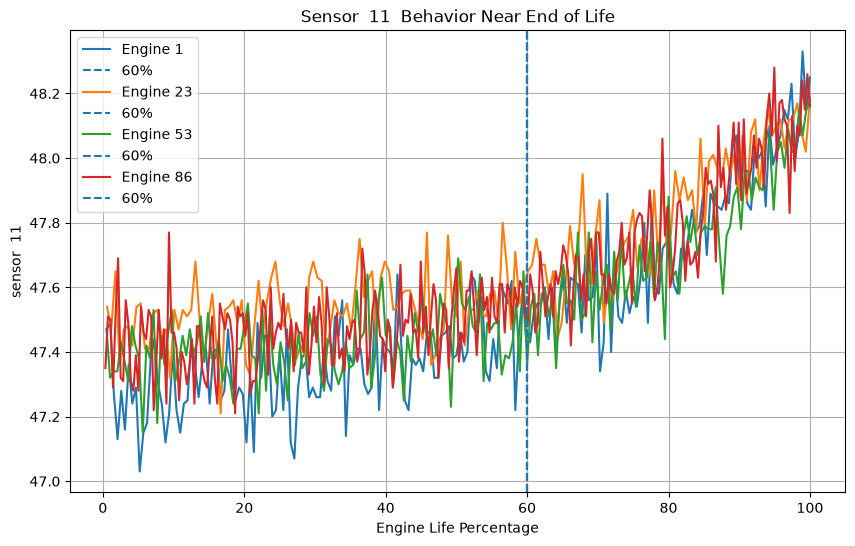

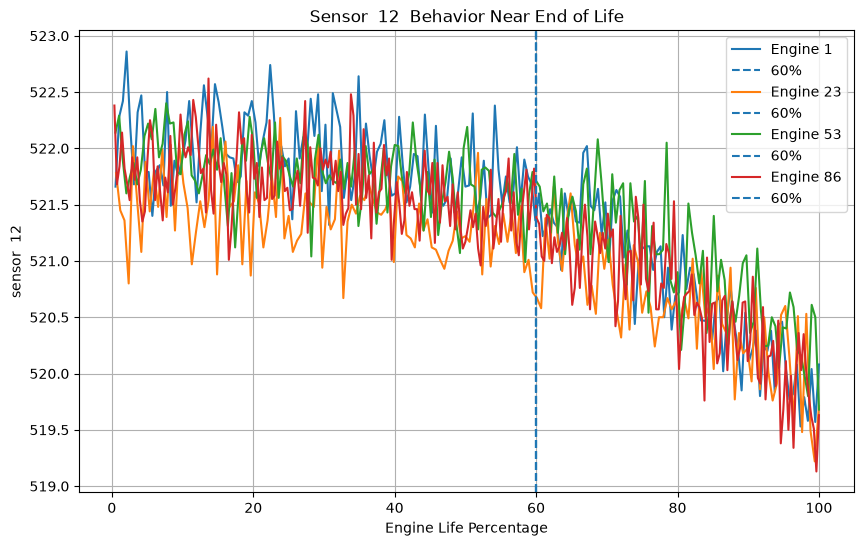

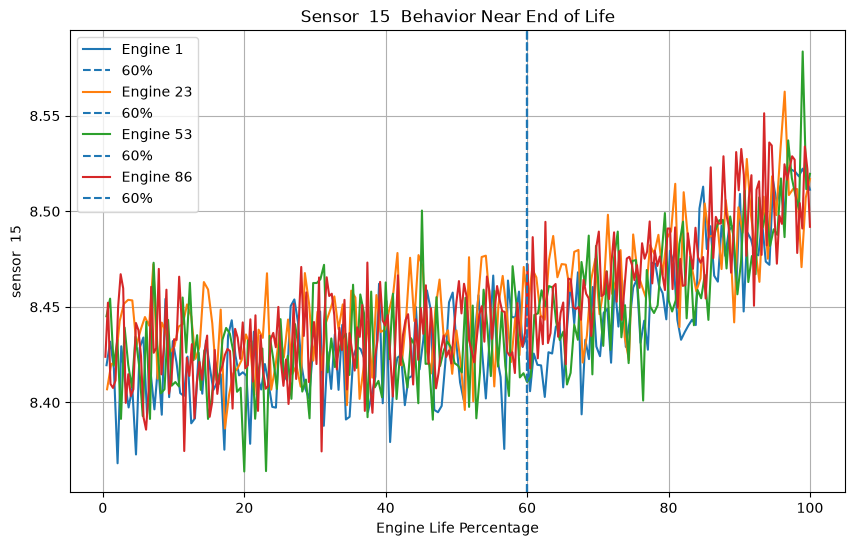

In [17]:
selected_engines=[1,23,53,86]

for sensor in key_sensors:
    plt.figure(figsize=(10,6))

    for engine in selected_engines:
        engine_data= df[df['engine_id']==engine]
        
        plt.plot(engine_data['life_percent'],engine_data[sensor],label=f"Engine {engine}")
        
        plt.axvline(60,linestyle='--',label="60%")
        
    plt.title(f'{sensor.replace('_','  ').title()}  Behavior Near End of Life')
    plt.xlabel('Engine Life Percentage')
    plt.ylabel(sensor.replace('_','  '))
    plt.legend()
    plt.savefig(f'../figures/{sensor.replace('_','  ').title()}  Behavior Near End of Life')
    
    plt.grid()
    plt.show()

Observations: 

Sensor 4: Values fluctuate around a relatively stable average early in engine life, with a slight increase around 40–60%. After 60%, the increase becomes more pronounced, with a much larger change from 80–100% (+10.38) than from 60–80%.

Sensor 11: Similar to Sensor 4, values remain relatively stable early on, followed by a slight increase around 40–60% and a more noticeable increase after 60%. The change between 60–80% and 80–100% is relatively small (+0.31).

Sensor 15: Values remain relatively stable during the early and middle stages, followed by a slight increase around 40–60% and a more noticeable increase after 60%. The change between the two later intervals is very small (+0.04).

Sensor 7: Values remain relatively stable early in engine life, followed by a small decrease around 40–60%. After 60%, the downward trend becomes more pronounced, with a change of −0.98 between the later intervals.

Sensor 12: Similar to Sensor 7, values remain relatively stable initially, followed by a small decrease around 40–60%. After 60%, the decrease becomes more pronounced, with a change of −0.83 between the 60–80% and 80–100% intervals.